In [43]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt

1. Cargar el dataset (ajusta la ruta a tu CSV)

In [44]:
import pandas as pd

df = pd.read_csv("data/fashion-mnist_train.csv")
print("Primeras filas del dataset:")
print(df.head())
print("Clases únicas:", df["label"].unique())


Primeras filas del dataset:
   label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      2       0       0       0       0       0       0       0       0   
1      9       0       0       0       0       0       0       0       0   
2      6       0       0       0       0       0       0       0       5   
3      0       0       0       0       1       2       0       0       0   
4      3       0       0       0       0       0       0       0       0   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0        30        43         0   
3       0  ...         3         0         0         0         0         1   
4       0  ...         0         0         0         0         0         0   

   pixel781  pixel782  pixel783  pixel784  
0 

In [45]:
y = df["label"].values
X = df.drop(columns=["label"]).values



2. Dividir en entrenamiento y prueba, estratificando por etiqueta:


In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Tamaño de X_train:", X_train.shape)
print("Tamaño de X_test:", X_test.shape)


Tamaño de X_train: (48000, 784)
Tamaño de X_test: (12000, 784)


Normalizar los datos

In [47]:
import numpy as np

mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
std[std == 0] = 1.0  # evitar división por cero

X_train_norm = (X_train - mean) / std
X_test_norm  = (X_test  - mean) / std


Convertir a tensores

In [48]:
import torch

X_train_t = torch.tensor(X_train_norm, dtype=torch.float32)
y_train_t = torch.tensor(y_train,      dtype=torch.long)
X_test_t  = torch.tensor(X_test_norm,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,       dtype=torch.long)


7. Entrenar el modelo


In [49]:
class ModelCustom2(nn.Module):
    def __init__(self, D_in=784, H=100, D_out=10):
        super().__init__()
        self.fc1 = nn.Linear(D_in, H)
        self.fc2 = nn.Linear(H, D_out)

    def forward(self, x):
        out = F.relu(self.fc1(x))
        out = self.fc2(out)
        return out

In [50]:

model = ModelCustom2(D_in=X_train_t.shape[1], H=100, D_out=len(torch.unique(y_train_t)))

# 6. Configurar pérdida y optimizador.
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.2)

# 7. Entrenar y almacenar la pérdida por época:contentReference[oaicite:5]{index=5}.
epochs = 100
log_each = 10
losses = []

model.train()
for e in range(1, epochs + 1):
    # Forward
    y_pred = model(X_train_t)

    # Calcular loss
    loss = criterion(y_pred, y_train_t)
    losses.append(loss.item())

    # Backprop y optimización
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if e % log_each == 0:
        print(f"Epoch {e}/{epochs}, Loss: {np.mean(losses[-log_each:]):.5f}")

Epoch 10/100, Loss: 1.27001
Epoch 20/100, Loss: 0.70614
Epoch 30/100, Loss: 0.59788
Epoch 40/100, Loss: 0.54321
Epoch 50/100, Loss: 0.51165
Epoch 60/100, Loss: 0.51243
Epoch 70/100, Loss: 0.46617
Epoch 80/100, Loss: 0.45108
Epoch 90/100, Loss: 0.43999
Epoch 100/100, Loss: 0.43441


8. Evaluar precisión en test


In [51]:
# 8. Evaluar precisión en test:contentReference[oaicite:6]{index=6}.
model.eval()
with torch.no_grad():
    y_pred_test = model(X_test_t)
    y_pred_labels = torch.argmax(y_pred_test, dim=1)

accuracy = accuracy_score(y_test, y_pred_labels.numpy())
print("Precisión en test:", accuracy)


Precisión en test: 0.83675


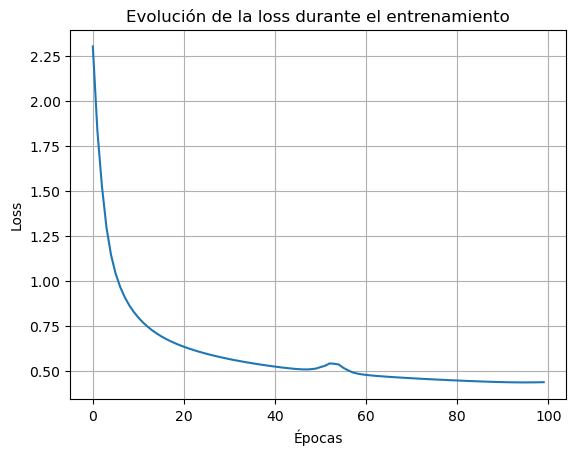

In [52]:
# 9. Graficar evolución de la loss.
plt.plot(losses)
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.title("Evolución de la loss durante el entrenamiento")
plt.grid(True)
plt.show()